# Medical Charges Prediction Project

This project aims to predict medical insurance charges using machine learning regression models.

## Initial Data Inspection

The dataset contains 1339 observations and 7 variables.

The features include both numerical and categorical variables:
- Numerical: age, bmi, children, charges
- Categorical: sex, smoker, region

The target variable is `charges`, which represents medical insurance costs.

From the initial inspection, the dataset appears clean, with appropriate data types.

In [2]:
import pandas as pd

df = pd.read_csv("medical-charges.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
df.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [4]:
df.shape

(1338, 7)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


In [6]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

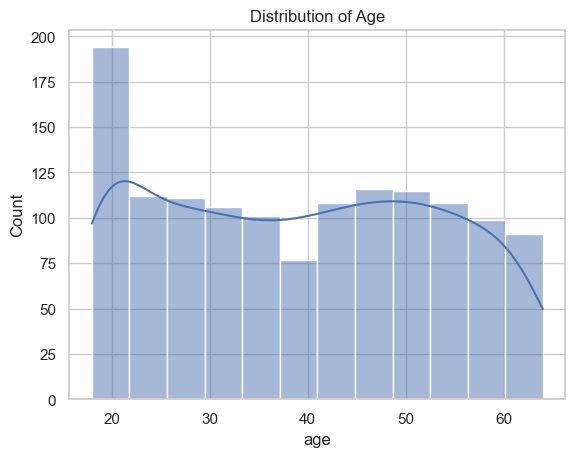

In [8]:
plt.figure()
sns.histplot(df['age'], kde=True)
plt.title("Distribution of Age")
plt.show()

### Age Distribution

The age variable is relatively uniformly distributed across the dataset, ranging from 18 to 64 years. 

There is no strong skewness observed, indicating a balanced representation of individuals across different age groups.

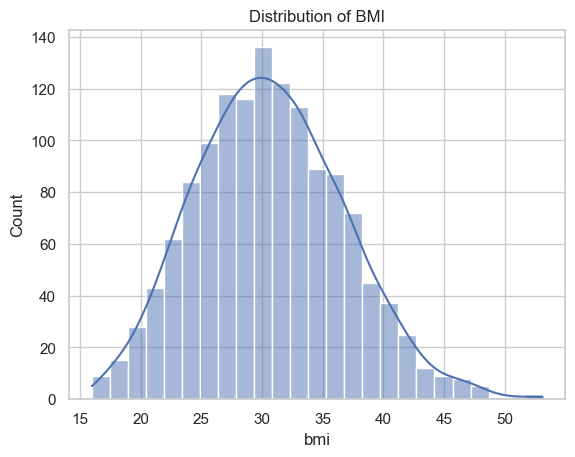

In [9]:
plt.figure()
sns.histplot(df['bmi'], kde=True)
plt.title("Distribution of BMI")
plt.show()

### BMI Distribution

The BMI variable follows an approximately normal distribution, with a slight right skew.

Most individuals have a BMI concentrated around the average range, while a few individuals exhibit higher BMI values, indicating possible outliers.

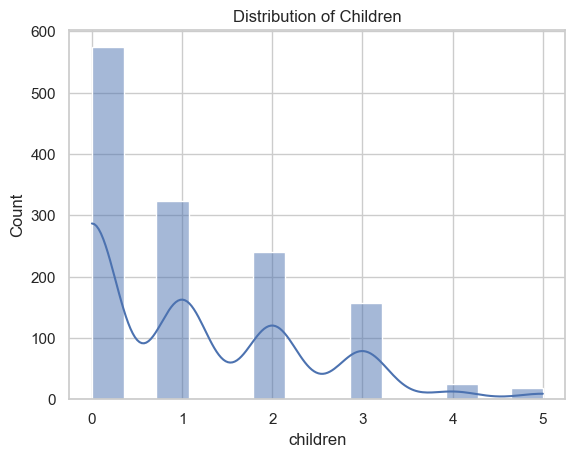

In [10]:
plt.figure()
sns.histplot(df['children'], kde=True)
plt.title("Distribution of Children")
plt.show()

### Children Distribution

The number of children is a discrete variable, with most individuals having 0 to 2 children.

Higher numbers of children are less frequent, which results in a decreasing distribution as the number of children increases.

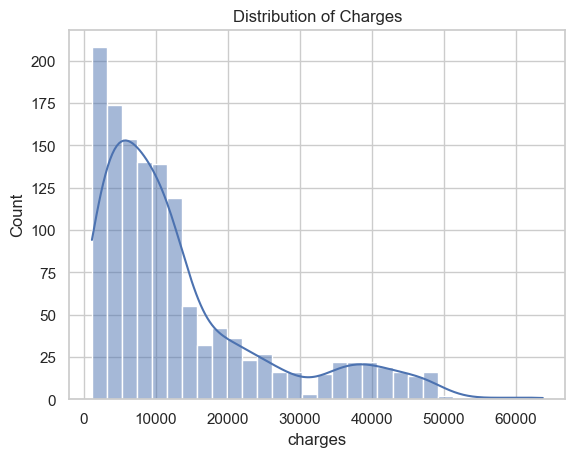

In [11]:
plt.figure()
sns.histplot(df['charges'], kde=True)
plt.title("Distribution of Charges")
plt.show()

### Charges Distribution

The distribution of medical charges is highly right-skewed.

Most individuals have relatively low medical expenses, while a small number of individuals incur very high charges. This creates a long right tail and indicates the presence of outliers.

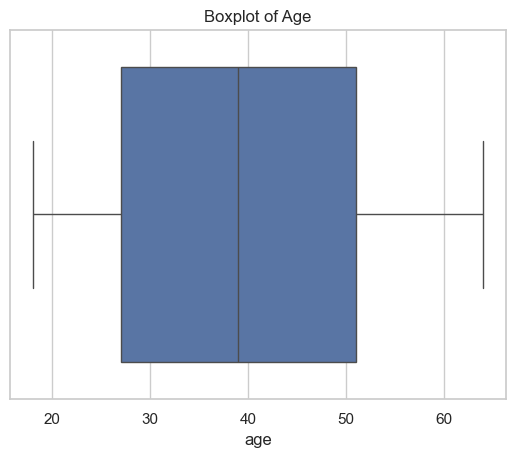

In [12]:
plt.figure()
sns.boxplot(x=df['age'])
plt.title("Boxplot of Age")
plt.show()

### Age Boxplot

The age variable does not show significant outliers and appears to be fairly uniformly distributed.

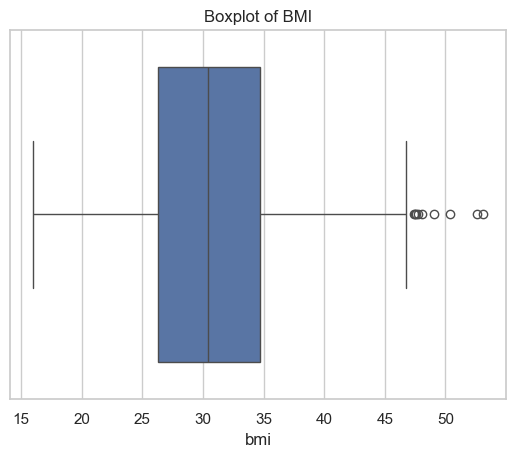

In [13]:
plt.figure()
sns.boxplot(x=df['bmi'])
plt.title("Boxplot of BMI")
plt.show()

### BMI Boxplot

The BMI variable shows a few outliers, indicating that some individuals have unusually high or low body mass index values.

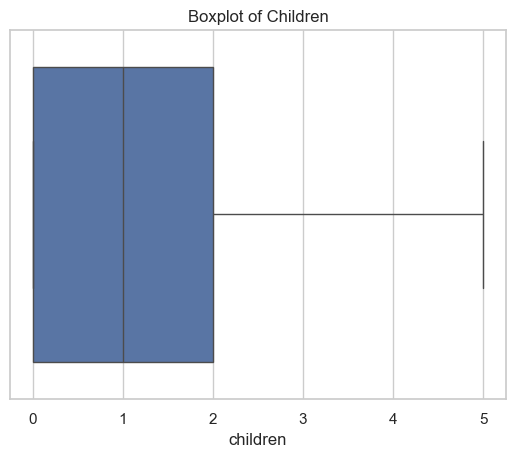

In [14]:
plt.figure()
sns.boxplot(x=df['children'])
plt.title("Boxplot of Children")
plt.show()

### Children Boxplot

The number of children is a discrete variable with limited range, and no significant outliers are observed.

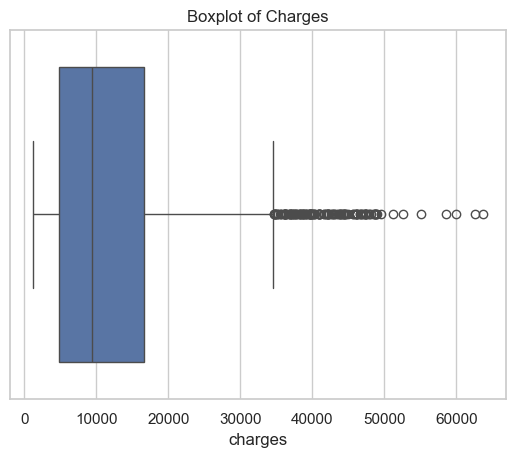

In [15]:
plt.figure()
sns.boxplot(x=df['charges'])
plt.title("Boxplot of Charges")
plt.show()

### Charges Boxplot

The boxplot of medical charges reveals a significant number of outliers on the upper end of the distribution.

These extreme values indicate that a subset of individuals incur substantially higher medical costs compared to the majority. Such outliers may have a strong impact on regression models and should be carefully considered during model evaluation.

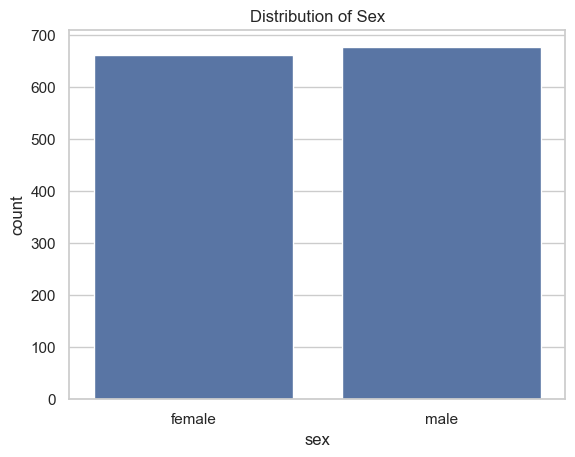

In [16]:
plt.figure()
sns.countplot(x=df['sex'])
plt.title("Distribution of Sex")
plt.show()

### Sex Distribution

The dataset is relatively balanced between male and female individuals, indicating no significant gender imbalance.

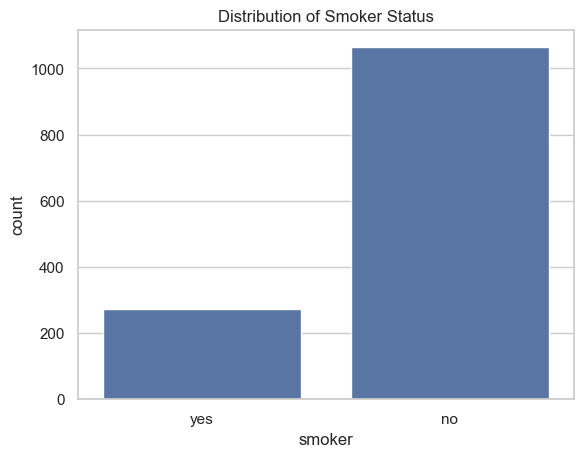

In [17]:
plt.figure()
sns.countplot(x=df['smoker'])
plt.title("Distribution of Smoker Status")
plt.show()

### Smoker Distribution

The majority of individuals in the dataset are non-smokers, while a smaller proportion are smokers.

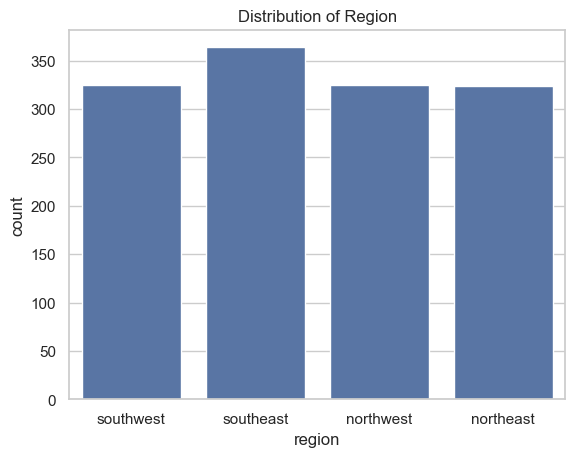

In [18]:
plt.figure()
sns.countplot(x=df['region'])
plt.title("Distribution of Region")
plt.show()

### Region Distribution

The individuals are fairly evenly distributed across the four regions, with no region being significantly overrepresented.

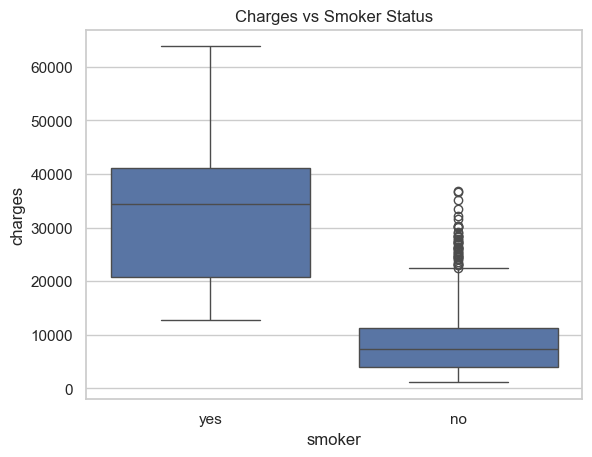

In [19]:
plt.figure()
sns.boxplot(x='smoker', y='charges', data=df)
plt.title("Charges vs Smoker Status")
plt.show()

### Impact of Smoking on Medical Charges

The boxplot clearly shows that smoking has a significant impact on medical charges.

Smokers tend to have substantially higher medical costs compared to non-smokers. The distribution of charges for smokers is not only higher but also more spread out, indicating greater variability.

This suggests that smoking is one of the most important factors influencing medical expenses.

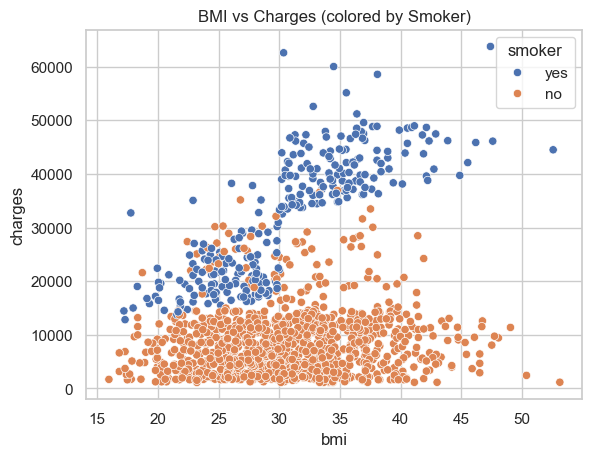

In [20]:
plt.figure()
sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df)
plt.title("BMI vs Charges (colored by Smoker)")
plt.show()

### Interaction between BMI and Smoking Status

The scatter plot reveals a strong interaction between BMI and smoking status.

For non-smokers, medical charges remain relatively moderate even as BMI increases. However, for smokers, higher BMI is associated with a significant increase in medical charges.

This indicates that the combination of smoking and high BMI leads to substantially higher healthcare costs.

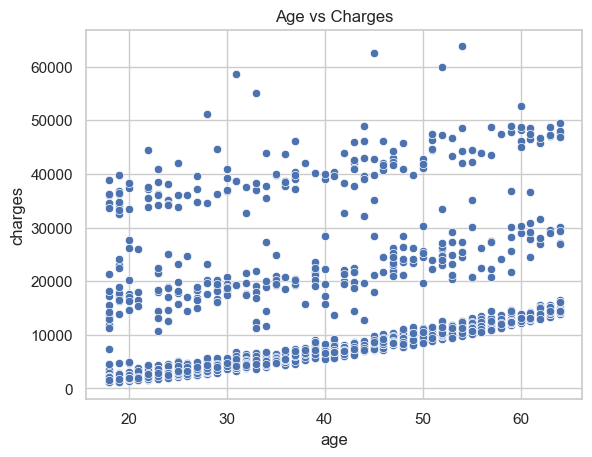

In [21]:
plt.figure()
sns.scatterplot(x='age', y='charges', data=df)
plt.title("Age vs Charges")
plt.show()

### Age vs Charges

There is a positive relationship between age and medical charges.

As age increases, medical costs tend to increase as well, although the relationship is not perfectly linear.

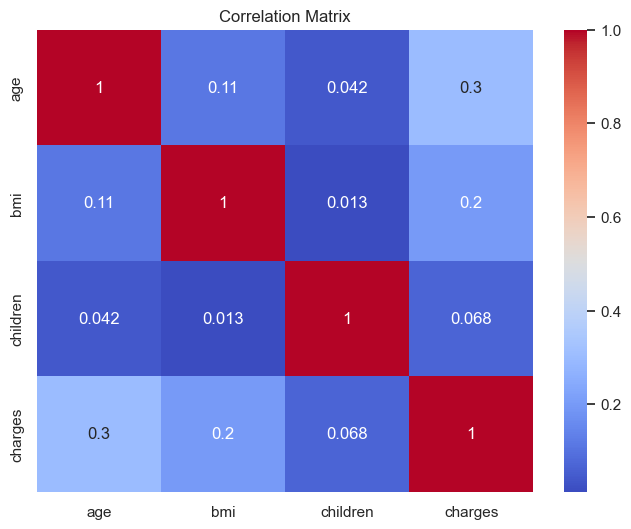

In [22]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

### Correlation Matrix

The correlation matrix shows the relationships between numerical variables.

The strongest correlation with the target variable `charges` is observed with `age` and `bmi`, although these relationships are moderate.

This suggests that other factors, particularly categorical variables such as smoking status, play a significant role in predicting medical charges.

In [23]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

### Missing Values

The dataset does not contain any missing values. Therefore, no imputation or removal is required.

In [24]:
df.duplicated().sum()

np.int64(1)

In [25]:
df = df.drop_duplicates()

### Duplicate Records

Duplicate rows were checked in the dataset. Any exact duplicates were removed to ensure data quality.

In [26]:
df = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)

### Encoding Categorical Variables

Categorical variables (`sex`, `smoker`, `region`) were transformed using One-Hot Encoding.

This method converts categorical variables into binary columns, making them suitable for regression models. The `drop_first=True` option was used to avoid multicollinearity.

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = ['age', 'bmi', 'children']

df[num_cols] = scaler.fit_transform(df[num_cols])

### Feature Scaling

Numerical variables (`age`, `bmi`, `children`) were standardized using StandardScaler.

This transformation ensures that all features have a mean of 0 and a standard deviation of 1, which improves the performance of regularized regression models.

In [28]:
from sklearn.model_selection import train_test_split

X = df.drop('charges', axis=1)
y = df['charges']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Train-Test Split

The dataset was split into training and testing sets using an 80/20 ratio.

The training set is used to train the models, while the test set is used to evaluate their performance on unseen data. A fixed random state ensures reproducibility.

In [29]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [30]:
y_pred_lr = lr.predict(X_test)

In [31]:
coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_
})

coeff_df

,Feature,Coefficient
0,age,3484.650051
1,bmi,1943.500851
2,children,642.341261
3,sex_male,-101.542054
4,smoker_yes,23077.764593
5,region_northwest,-391.761455
6,region_southeast,-838.919616
7,region_southwest,-659.139752


### Linear Regression Model

A Linear Regression model was trained using the training dataset.

The coefficients indicate the relationship between each feature and the target variable (charges). A positive coefficient means that the feature increases medical charges, while a negative coefficient decreases them.

The smoking variable is expected to have the strongest impact on medical charges.

In [32]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)

ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)

In [33]:
ridge_coeff = pd.DataFrame({
    'Feature': X.columns,
    'Ridge Coefficient': ridge.coef_
})

ridge_coeff

,Feature,Ridge Coefficient
0,age,3480.028098
1,bmi,1938.779627
2,children,643.171528
3,sex_male,-91.825130
4,smoker_yes,22940.789219
5,region_northwest,-389.106980
6,region_southeast,-819.797685
7,region_southwest,-652.670986


### Ridge Regression Model

Ridge Regression was applied to introduce L2 regularization, which penalizes large coefficients.

Compared to standard linear regression, Ridge reduces the magnitude of coefficients, helping to prevent overfitting and improving model stability.

In [34]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1)

lasso.fit(X_train, y_train)

y_pred_lasso = lasso.predict(X_test)

In [35]:
lasso_coeff = pd.DataFrame({
    'Feature': X.columns,
    'Lasso Coefficient': lasso.coef_
})

lasso_coeff

,Feature,Lasso Coefficient
0,age,3484.585696
1,bmi,1943.260680
2,children,642.252779
3,sex_male,-101.068184
4,smoker_yes,23077.087294
5,region_northwest,-390.074759
6,region_southeast,-837.064322
7,region_southwest,-657.403495


### Lasso Regression Model

Lasso Regression was applied using L1 regularization.

In this case, none of the coefficients were reduced to zero, indicating that all features contribute to the prediction of medical charges.

This suggests that each variable carries some predictive information, although their importance may vary.

In [36]:
from sklearn.linear_model import ElasticNet

elastic = ElasticNet(alpha=0.1, l1_ratio=0.5)

elastic.fit(X_train, y_train)

y_pred_elastic = elastic.predict(X_test)

In [37]:
elastic_coeff = pd.DataFrame({
    'Feature': X.columns,
    'ElasticNet Coefficient': elastic.coef_
})

elastic_coeff

,Feature,ElasticNet Coefficient
0,age,3263.476712
1,bmi,1757.721720
2,children,667.764369
3,sex_male,230.500494
4,smoker_yes,17502.347082
5,region_northwest,-349.980604
6,region_southeast,-219.704063
7,region_southwest,-479.401264


### ElasticNet Regression Model

ElasticNet combines both L1 and L2 regularization techniques.

It balances the benefits of Ridge and Lasso by both shrinking coefficients and potentially performing feature selection.

This approach is useful when dealing with correlated features and provides a flexible regularization framework.

In [38]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

In [39]:
def evaluate_model(y_test, y_pred):
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    return rmse, mae, r2

In [40]:
lr_metrics = evaluate_model(y_test, y_pred_lr)
ridge_metrics = evaluate_model(y_test, y_pred_ridge)
lasso_metrics = evaluate_model(y_test, y_pred_lasso)
elastic_metrics = evaluate_model(y_test, y_pred_elastic)

In [41]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge', 'Lasso', 'ElasticNet'],
    'RMSE': [lr_metrics[0], ridge_metrics[0], lasso_metrics[0], elastic_metrics[0]],
    'MAE': [lr_metrics[1], ridge_metrics[1], lasso_metrics[1], elastic_metrics[1]],
    'R2': [lr_metrics[2], ridge_metrics[2], lasso_metrics[2], elastic_metrics[2]]
})

results

,Model,RMSE,MAE,R2
0,Linear Regression,5956.342894,4177.045561,0.806929
1,Ridge,5971.866625,4193.886538,0.805921
2,Lasso,5956.469620,4177.118530,0.806920
3,ElasticNet,6964.339465,4986.194227,0.736052


### Model Evaluation

The performance of each regression model was evaluated using RMSE, MAE, and R² metrics.

- RMSE measures the average magnitude of prediction errors.
- MAE represents the average absolute error.
- R² indicates the proportion of variance explained by the model.

The best model is the one with the lowest RMSE and MAE, and the highest R² score.

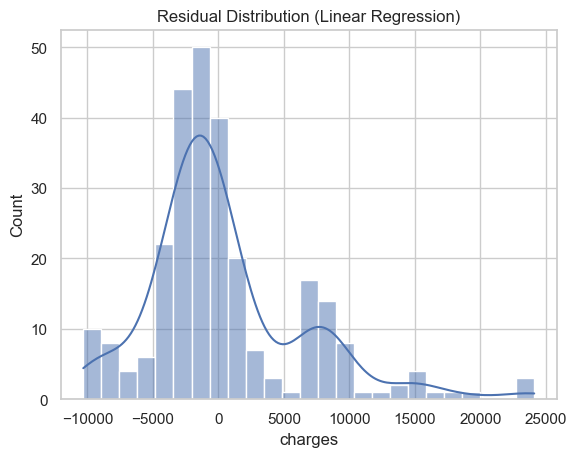

In [42]:
residuals = y_test - y_pred_lr

plt.figure()
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution (Linear Regression)")
plt.show()

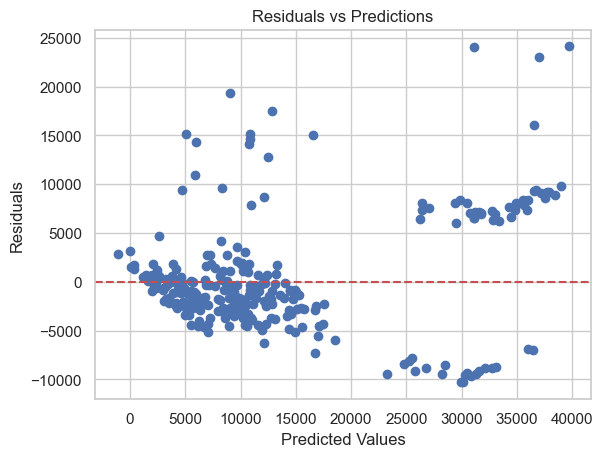

In [43]:
plt.figure()
plt.scatter(y_pred_lr, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predictions")
plt.show()

### Residual Analysis

The residuals appear to be centered around zero, which indicates that the model does not have a strong systematic bias.

However, the spread of residuals suggests that the model may not perfectly capture all patterns in the data.

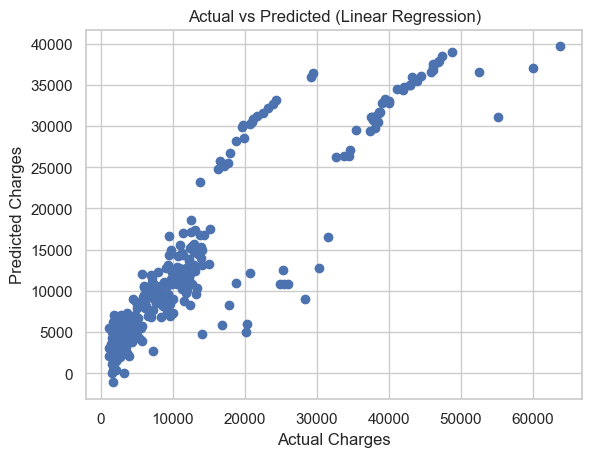

In [44]:
plt.figure()
plt.scatter(y_test, y_pred_lr)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted (Linear Regression)")
plt.show()

### Actual vs Predicted Values

The scatter plot shows the relationship between actual and predicted values.

A perfect model would produce points along a diagonal line. The observed dispersion indicates that while the model captures the general trend, there are prediction errors.

### Model Comparison

The evaluation results show that Linear Regression and Lasso Regression provide the best performance, with the lowest RMSE and MAE values, and the highest R² scores.

Ridge Regression performs similarly, indicating that the model is stable and does not suffer significantly from overfitting.

ElasticNet, however, shows a noticeable decrease in performance, suggesting that excessive regularization may reduce the model's ability to capture important patterns in the data.

Overall, Linear Regression is identified as the best-performing model for this dataset.

In [45]:
import statsmodels.api as sm

In [46]:
X_sm = sm.add_constant(X)

In [47]:
X.dtypes

age                 float64
bmi                 float64
children            float64
sex_male               bool
smoker_yes             bool
region_northwest       bool
region_southeast       bool
region_southwest       bool
dtype: object

In [48]:
X = X.apply(pd.to_numeric)

In [49]:
X = X.astype(float)

In [50]:
import statsmodels.api as sm

X_sm = sm.add_constant(X)

In [51]:
model = sm.OLS(y, X_sm).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                charges   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     500.0
Date:                Tue, 21 Apr 2026   Prob (F-statistic):               0.00
Time:                        20:41:44   Log-Likelihood:                -13538.
No. Observations:                1337   AIC:                         2.709e+04
Df Residuals:                    1328   BIC:                         2.714e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const             9057.1652    386.299     23.446      0.000    8299.343    9814.988
age               3604.7388    167.237     21.555      0.000    3276.662    3932.815
bmi               2068.8120    174.477     11.857      0.000    1726.532    2411.092
children           572.2159    166.182      3.443      0.001     246.207     898.225
sex_male          -129.4815    333.195     -0.389      0.698    -783.128     524.165
smoker_yes        2.385e+04    413.348     57.693      0.000     2.3e+04    2.47e+04
region_northwest  -349.2265    476.824     -0.732      0.464   -1284.637     586.183
region_southeast -1035.2656    478.867     -2.162      0.031   -1974.684     -95.847
region_southwest  -960.0814    478.106     -2.008      0.045   -1898.007     -22.156
==============================================================================
Omnibus:                      299.816   Durbin-Watson:                   2.089
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              716.552
Skew:                           1.211   Prob(JB):                    2.53e-156
Kurtosis:                       5.646   Cond. No.                         5.63
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [52]:
X = X.drop('sex_male', axis=1)

In [53]:
X_sm = sm.add_constant(X)

model = sm.OLS(y, X_sm).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                charges   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     571.8
Date:                Tue, 21 Apr 2026   Prob (F-statistic):               0.00
Time:                        20:41:44   Log-Likelihood:                -13538.
No. Observations:                1337   AIC:                         2.709e+04
Df Residuals:                    1329   BIC:                         2.713e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const             8993.7070    349.975     25.698      0.000    8307.143    9680.271
age               3606.2898    167.135     21.577      0.000    3278.412    3934.168
bmi               2065.6537    174.232     11.856      0.000    1723.854    2407.453
children           571.0619    166.103      3.438      0.001     245.210     896.914
smoker_yes        2.384e+04    412.038     57.847      0.000     2.3e+04    2.46e+04
region_northwest  -348.2514    476.665     -0.731      0.465   -1283.349     586.846
region_southeast -1034.6268    478.711     -2.161      0.031   -1973.739     -95.515
region_southwest  -959.4167    477.950     -2.007      0.045   -1897.036     -21.798
==============================================================================
Omnibus:                      300.175   Durbin-Watson:                   2.090
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              718.139
Skew:                           1.211   Prob(JB):                    1.14e-156
Kurtosis:                       5.650   Cond. No.                         5.02
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Backward Elimination Process

The backward elimination process started by removing the feature with the highest p-value greater than 0.05.

The variable `sex_male` was removed first, as it showed no statistical significance in predicting medical charges.

The model was then refitted, and the process was repeated until all remaining variables were statistically significant.

In [54]:
X = X.drop('region_northwest', axis=1)

In [55]:
X_sm = sm.add_constant(X)

model = sm.OLS(y, X_sm).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                charges   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     667.2
Date:                Tue, 21 Apr 2026   Prob (F-statistic):               0.00
Time:                        20:41:44   Log-Likelihood:                -13538.
No. Observations:                1337   AIC:                         2.709e+04
Df Residuals:                    1330   BIC:                         2.713e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const             8818.1564    254.409     34.661      0.000    8319.069    9317.243
age               3606.5528    167.106     21.582      0.000    3278.733    3934.372
bmi               2065.5707    174.201     11.857      0.000    1723.832    2407.310
children           567.3483    165.996      3.418      0.001     241.706     892.991
smoker_yes        2.384e+04    411.844     57.892      0.000     2.3e+04    2.47e+04
region_southeast  -861.0086    415.490     -2.072      0.038   -1676.096     -45.921
region_southwest  -785.0378    414.015     -1.896      0.058   -1597.232      27.156
==============================================================================
Omnibus:                      299.563   Durbin-Watson:                   2.093
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              714.234
Skew:                           1.211   Prob(JB):                    8.05e-156
Kurtosis:                       5.638   Cond. No.                         3.44
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

The variable `region_northwest` was also removed due to its high p-value, indicating a lack of statistical significance.

The model was updated accordingly and re-evaluated.

In [56]:
X = X.drop('region_southwest', axis=1)

In [57]:
X_sm = sm.add_constant(X)

model = sm.OLS(y, X_sm).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                charges   R-squared:                       0.750
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     798.4
Date:                Tue, 21 Apr 2026   Prob (F-statistic):               0.00
Time:                        20:41:44   Log-Likelihood:                -13540.
No. Observations:                1337   AIC:                         2.709e+04
Df Residuals:                    1331   BIC:                         2.712e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const             8548.7692    211.251     40.467      0.000    8134.348    8963.190
age               3608.6782    167.265     21.575      0.000    3280.547    3936.810
bmi               2033.7177    173.558     11.718      0.000    1693.240    2374.195
children           563.3187    166.144      3.391      0.001     237.386     889.251
smoker_yes        2.385e+04    412.209     57.866      0.000     2.3e+04    2.47e+04
region_southeast  -580.2620    388.592     -1.493      0.136   -1342.582     182.058
==============================================================================
Omnibus:                      302.362   Durbin-Watson:                   2.090
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              724.584
Skew:                           1.219   Prob(JB):                    4.56e-158
Kurtosis:                       5.657   Cond. No.                         2.74
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Final Model after Backward Elimination

After applying the backward elimination process, the final model retains only statistically significant variables.

The variables `sex_male`, `region_northwest`, and `region_southwest` were removed due to their high p-values, indicating a lack of statistical significance.

The final model includes:
- age
- bmi
- children
- smoker status
- region_southeast

Among these, smoking remains the most influential factor affecting medical charges, followed by age and BMI.

This final model is more interpretable and statistically robust.

### Discussion of Results

The objective of this project was to analyze and predict medical insurance charges using multiple regression models, while also identifying the most influential factors affecting these costs.

The comparative evaluation of the models shows that Linear Regression and Lasso Regression achieved the best overall performance, with the lowest RMSE and MAE values and the highest R² scores (approximately 0.81). Ridge Regression produced very similar results, indicating that the model is stable and does not suffer significantly from overfitting. In contrast, ElasticNet showed a noticeable decrease in performance, suggesting that the level of regularization applied was too strong and led to a loss of important information.

These results indicate that the relationship between the input variables and the target variable is largely linear, which explains why simple Linear Regression performs as well as, or better than, more complex regularized models. The minimal performance difference between Linear, Ridge, and Lasso models further confirms that the dataset does not exhibit severe multicollinearity or overfitting issues.

From an interpretability perspective, the analysis of regression coefficients and the backward elimination process provided valuable insights into the importance of each feature. The variable representing smoking status consistently showed the strongest impact on medical charges, with a significantly large positive coefficient. This finding is consistent across all models and aligns with real-world expectations, as smoking is known to increase health risks and associated medical costs.

Other variables such as age and BMI were also found to have a meaningful positive influence on charges, indicating that older individuals and those with higher body mass index tend to incur higher medical expenses. The number of children showed a smaller but still statistically significant effect.

On the other hand, variables such as gender and certain regional indicators were found to be statistically insignificant and were removed during the backward elimination process. This suggests that these features do not contribute meaningfully to the prediction of medical charges in this dataset.

Overall, the results demonstrate that a relatively simple and interpretable model can effectively capture the main factors influencing medical insurance costs. The combination of machine learning evaluation and statistical inference provides both predictive accuracy and meaningful insights into the underlying data.


In [58]:
selected_features = ['age', 'bmi', 'children', 'smoker_yes', 'region_southeast']

In [59]:
X_all = df.drop('charges', axis=1)
X_selected = df[selected_features]

y = df['charges']

In [60]:
from sklearn.model_selection import train_test_split

X_train_all, X_test_all, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

X_train_sel, X_test_sel, _, _ = train_test_split(
    X_selected, y, test_size=0.2, random_state=42
)

In [61]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1),
    "ElasticNet": ElasticNet(alpha=0.1, l1_ratio=0.5)
}

results = []

In [62]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def evaluate(y_test, y_pred, X):
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    n = len(y_test)
    p = X.shape[1]
    adj_r2 = 1 - (1 - r2)*(n - 1)/(n - p - 1)
    return rmse, mae, r2, adj_r2

In [63]:
for name, model in models.items():
    
    # ALL features
    model.fit(X_train_all, y_train)
    y_pred_all = model.predict(X_test_all)
    rmse_all, mae_all, r2_all, adj_r2_all = evaluate(y_test, y_pred_all, X_test_all)
    
    # SELECTED features
    model.fit(X_train_sel, y_train)
    y_pred_sel = model.predict(X_test_sel)
    rmse_sel, mae_sel, r2_sel, adj_r2_sel = evaluate(y_test, y_pred_sel, X_test_sel)
    
    results.append([
        name,
        rmse_all, mae_all, r2_all, adj_r2_all,
        rmse_sel, mae_sel, r2_sel, adj_r2_sel
    ])

In [64]:
import pandas as pd

comparison_df = pd.DataFrame(results, columns=[
    "Model",
    "RMSE_All", "MAE_All", "R2_All", "AdjR2_All",
    "RMSE_Selected", "MAE_Selected", "R2_Selected", "AdjR2_Selected"
])

comparison_df

,Model,RMSE_All,MAE_All,R2_All,AdjR2_All,RMSE_Selected,MAE_Selected,R2_Selected,AdjR2_Selected
0,Linear,5956.342894,4177.045561,0.806929,0.800965,5980.943900,4190.783550,0.805331,0.801615
1,Ridge,5971.866625,4193.886538,0.805921,0.799926,5996.054291,4208.204409,0.804346,0.800612
2,Lasso,5956.469620,4177.118530,0.806920,0.800957,5981.034331,4190.851578,0.805325,0.801609
3,ElasticNet,6964.339465,4986.194227,0.736052,0.727899,6971.154099,4993.380595,0.735535,0.730488


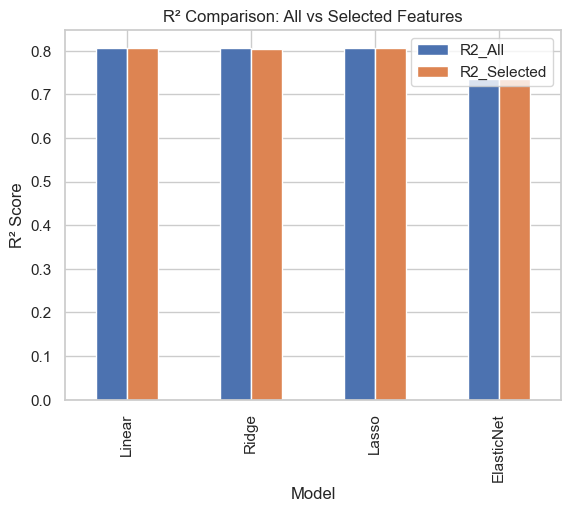

In [65]:
import matplotlib.pyplot as plt

comparison_df.set_index("Model")[["R2_All", "R2_Selected"]].plot(kind="bar")
plt.title("R² Comparison: All vs Selected Features")
plt.ylabel("R² Score")
plt.show()

### Comparison: All Features vs Selected Features

The comparison between models trained on all features and those trained on selected features shows that the overall performance remains very similar.

The evaluation metrics (RMSE, MAE, R², Adjusted R²) indicate that using a reduced set of features does not significantly degrade model performance. In some cases, the selected-feature models achieve nearly identical results.

This suggests that the removed variables (such as gender and certain regional indicators) do not contribute meaningful predictive power.

Moreover, the reduced model is simpler and more interpretable, with fewer variables, while maintaining comparable accuracy. This highlights the effectiveness of the backward elimination process.

Overall, feature selection allowed us to simplify the model without sacrificing performance, which is desirable in practical applications.

## Conclusion

This project aimed to analyze and predict medical insurance charges using machine learning techniques while identifying the most influential factors affecting these costs.

The results show that Linear Regression is the best-performing model, achieving the lowest error metrics and the highest R² score. Regularized models such as Ridge and Lasso produced similar results, confirming the stability of the dataset, while ElasticNet showed slightly lower performance due to stronger regularization.

The analysis highlighted smoking status as the most important factor influencing medical charges, with a very strong positive effect. Age and BMI were also identified as significant predictors, contributing positively to the increase in medical costs.

Through feature selection using backward elimination, less relevant variables such as gender and certain regional indicators were removed. The comparison between models trained on all features and those trained on selected features demonstrated that a simpler model can achieve nearly the same performance, improving interpretability without compromising accuracy.

### Key Observations

* Smoking has a dominant impact on medical charges
* Age and BMI significantly influence healthcare costs
* Some variables (e.g., gender) have negligible effect

### Limitations

* The dataset size is relatively limited, which may affect generalization
* The models assume linear relationships between variables and the target
* Some potentially relevant variables (e.g., lifestyle, medical history) are not included

### Perspectives for Improvement

* Explore non-linear models such as Decision Trees, Random Forest, or XGBoost
* Apply feature engineering techniques (interaction terms, polynomial features)
* Use larger and more diverse datasets to improve model robustness

Overall, this project demonstrates that simple and interpretable machine learning models can effectively predict medical charges and provide valuable insights into the key factors influencing healthcare costs.
